Today's topics:
* fitting a line with `linregress`
* interpreting slope, intercept, and predictions
* residuals and evaluation metrics

# Predicting tensile strength from yield strength

Last time we measured how strongly yield strength and ultimate tensile strength trend together in titanium alloys: $r = 0.882$.

Today we will fit a line (a *model*) to those same measurements, use it to predict tensile strength, and see how far off each prediction is.

> The dataset is [Salvador et al., *Scientific Data* 9, 188](https://doi.org/10.1038/s41597-022-01283-9), CC BY 4.0.

In [1]:
import pandas as pd

data = pd.read_csv('https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/biomaterials_ti_alloys.csv')

In [2]:
import numpy as np
from scipy import stats

both = data.dropna(subset=['YS_MPa', 'UTS_MPa'])  # recall we need paired data
x = both['YS_MPa']
y = both['UTS_MPa']
print(f'{len(both)} alloys, same as L12')

190 alloys, same as L12


# Modeling

## What is a model?

Given an alloy's yield strength, what is its ultimate tensile strength likely to be?

So far, we looked at *correlation* which is how strongly these are related.

Next we'll try to produce a **model**.
A model is a simplified representation of a system.

We'll design it to answer a practical question - it is not an exact description!

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/b1/Global_Climate_Model.png/960px-Global_Climate_Model.png" alt="A globe wrapped in a latitude-longitude grid with a cutaway showing vertical layers, and an inset of the processes computed in each grid cell: clouds, oceans, volcanoes, vegetation, cities and ice sheets" width=620/>

*Schematic by NOAA, public domain, [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Global_Climate_Model.png).*

Above: A global atmospheric model divides the planet into a grid and computes the physics in each cell.


Is a weather model always right? 

> "All models are wrong but some are useful." - George Box

Is it a model of every atom in the atmosphere?

> "If you wish to bake an apple pie from scratch, you must first invent the universe." - Carl Sagan

## Fitting a line: `stats.linregress`

$r$ describes how closely the points follow a line, but not the line's slope or intercept.
`stats.linregress` fits $y = m x + b$ by "least squares" and returns an object with named fields ("attributes").

Least squares returns the line with the smallest total squared deviations from the data (it is closely related to the squared deviations we used to build `r` in L12).

In [3]:
fit = stats.linregress(x, y)

print(f'slope     = {fit.slope:.3f}')
print(f'intercept = {fit.intercept:.1f} MPa')
print(f'r         = {fit.rvalue:.3f}')

slope     = 0.985
intercept = 204.3 MPa
r         = 0.882


`fit.rvalue` is the same 0.882 that `stats.pearsonr` returned as `r` in L12.
The fit contains it because the correlation and the line are two different answers to the same question about these columns (how strongly are they correlated?).

## Reading the fitted equation

The fitted line is $\mathrm{UTS}_\mathrm{pred} = 0.985\,\mathrm{YS} + 204$.

Because both axes use MPa, the slope means 0.985 MPa of predicted tensile strength per 1 MPa of yield strength.

The intercept is the model's predicted tensile strength at zero yield strength (not really a physical quantity in this case).

# Prediction

# Scalar prediction

Substituting a yield strength into the fitted equation gives a predicted tensile strength.

In [4]:
pred_800 = fit.slope * 800 + fit.intercept
print(f'800 MPa yield strength predicts {pred_800:.0f} MPa tensile strength')

800 MPa yield strength predicts 992 MPa tensile strength


## Vectorized prediction

Above we predicted tensile strength from one yield strength at a time.
Broadcasting the equation over the yield-strength column predicts a tensile strength for every alloy.

In [5]:
y_hat = fit.slope * x + fit.intercept  # returns 190 predictions (broadcasting)
display(y_hat)

12      546.897436
13      800.917610
14      819.624522
15      823.562820
20      732.981982
          ...     
278    1753.985553
279    1878.041917
280    1651.589824
281    1779.584485
282    2055.265295
Name: YS_MPa, Length: 190, dtype: float64

## Drawing the fitted line

A straight line requires only two points, so use the smallest and largest yield strengths to draw the fitted line.

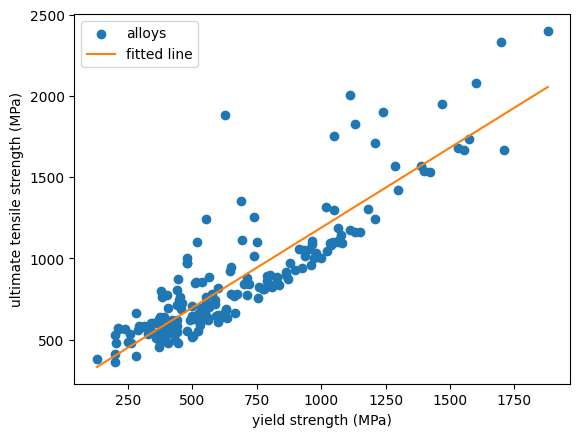

In [6]:
import matplotlib.pyplot as plt

xx = np.array([np.min(x), np.max(x)])
yy = fit.slope * xx + fit.intercept

fig, ax = plt.subplots()
ax.scatter(x, y, label='alloys')
ax.plot(xx, yy, color='tab:orange', label='fitted line')
ax.set_xlabel('yield strength (MPa)')
ax.set_ylabel('ultimate tensile strength (MPa)')
ax.legend()

## Residuals

A residual is measured UTS minus predicted UTS: $e_i = y_i - \hat{y}_i$. (here e might stand for "error")

In [7]:
residuals = y - y_hat  # measured minus predicted, so negative means the line was too optimistic
display(residuals)
print(f'sum of residuals: {np.sum(residuals):.6f}')  # zero, up to rounding

12      54.102564
13    -167.917610
14    -163.624522
15    -134.562820
20     119.018018
          ...    
278    -21.985553
279    453.958083
280    298.410176
281    300.415515
282    344.734705
Length: 190, dtype: float64

sum of residuals: 0.000000


For a least-squares fit evaluated on the data it was fit to, the residuals always sum to zero.
Positive and negative residuals cancel in the sum, so we use their spread to assess the fit.

## A visual look at the residuals

The histogram shows the distribution of all the residuals:

Text(0, 0.5, 'number of alloys')

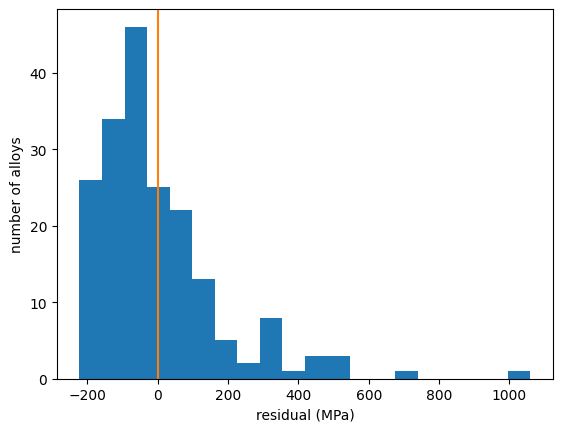

In [8]:
fig, ax = plt.subplots()
ax.hist(residuals, bins=20)
ax.axvline(0, color='tab:orange')  # a vertical line at zero residual
ax.set_xlabel('residual (MPa)')
ax.set_ylabel('number of alloys')

Most alloys sit within a couple of hundred MPa of the line, on both sides of zero, and a few are way out on the tail.

## MSE and RMSE

Squaring each residual before averaging stops the signs from cancelling.
The average of the squares is the mean squared error.

In [9]:
mse = np.mean(residuals ** 2)
print(f'MSE  = {mse:.0f} MPa^2')
print(f'RMSE = {np.sqrt(mse):.1f} MPa')

MSE  = 32797 MPa^2
RMSE = 181.1 MPa


Squared residuals have units of MPa squared, so MSE is also in MPa squared.

The square root gives RMSE in MPa: 181.1 MPa for these alloys.

A typical miss is on the order of 181 MPa for these alloys, though individual residuals vary.

## MAE

`np.abs` returns the magnitude of each residual, which also stops the signs cancelling.
The average of those is the mean absolute error, and it is in MPa already.

In [10]:
mae = np.mean(np.abs(residuals))
print(f'MAE  = {mae:.1f} MPa')

MAE  = 129.9 MPa


The MAE comes out smaller than the RMSE.
Because RMSE squares the residuals, the few large misses increase RMSE more than they increase MAE.

# $R^2$

RMSE is in MPa. Interpreting it requires a lot of context about the data.

$R^2$ is the fraction of variance in UTS explained by the fitted line, compared with always predicting the mean.

$R^2 = 1 - \frac{\mathrm{var}(y - \hat{y})}{\mathrm{var}(y)}$

Like Pearson's $r$, it is dimensionless and bounded. In this case, from 0 to +1. ($R^2$ is equivalent to the Pearson $r$, squared).

So the "explained variance" is how much of the variance in the data is explained by drawing a trendline.
A bad trendline won't explain any of it (0) while a good trendline explains most or all of it (1).

In [11]:
r_squared = 1 - np.var(residuals) / np.var(y)
print(f'R² = {r_squared:.4f}')
print(f"fit.rvalue ** 2 = {fit.rvalue ** 2:.4f}")  # the same number

R² = 0.7782
fit.rvalue ** 2 = 0.7782


Again, an $R^2$ of 0 means the line explains no more variance than the mean-only prediction, and 1 means its residuals are zero.

An $R^2$ of 0.78 means the line explains 78% of the variance in UTS across these alloys compared with the mean-only prediction.
The unexplained variation likely includes effects of composition, processing route, and microstructure, none of which are in this two-column fit.

### [Check your understanding]

`Mo_equivalent` is an engineered descriptor of how strongly an alloy favors the body-centered-cubic beta phase, computed from this table's own composition columns rather than measured on a testing machine.
Fit yield strength against `Mo_equivalent` and compare its $R^2$ with the UTS fit.

1. Build `has_mo`, the rows with both `Mo_equivalent` and `YS_MPa`, using `.dropna(subset=[...])`.
2. Fit `stats.linregress` with `Mo_equivalent` as x and `YS_MPa` as y, and print how many alloys went into it.
3. Compute that fit's residuals, and its $R^2$ from the mean baseline the way we did above.
4. Print `fit_mo.rvalue ** 2` as well and check the two agree.
5. In a comment, compare that $R^2$ with 0.78 and say how much the line improves on always predicting mean yield strength.

*Composition sets the phase an alloy favors, while grain size, processing route and heat treatment are nowhere in `Mo_equivalent`.*

*What does the $R^2$ you computed support saying about predicting yield strength from beta stability alone?*

# The residual plot

$R^2$ is one number for all 190 residuals.
Plot residuals against yield strength to check whether their size or sign changes across the fitted range.

`ax.axhline(0)` draws a horizontal line across the whole plot at zero, where a perfect prediction would sit.

Residuals scattered around zero with no visible pattern support a straight-line shape for the fit.

A visible curve or trend in the residuals indicates a systematic pattern missed by the straight line.

Text(0, 0.5, 'residual (MPa)')

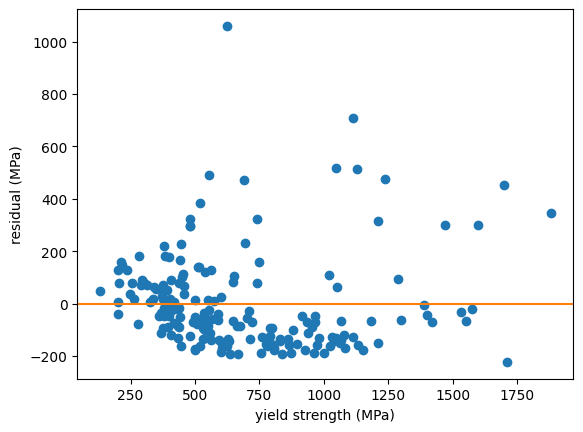

In [12]:
fig, ax = plt.subplots()
ax.scatter(x, residuals)
ax.axhline(0, color='tab:orange')
ax.set_xlabel('yield strength (MPa)')
ax.set_ylabel('residual (MPa)')

Ours has no discernable pattern, so a straight line is a reasonable shape for this data.
Maybe a slight curvature in the middle/bottom, but that is also an effect of having a few very large positive residuals above.

### [Check your understanding]

Run the whole diagnosis again on a different property pair: yield strength against Young's modulus.

1. Build `has_ym`, the rows with both `YM_GPa` and `YS_MPa`, using `.dropna(subset=[...])`.
2. Fit `stats.linregress` with `YS_MPa` as x and `YM_GPa` as y, and print the $R^2$.
3. Compute the residuals of that fit.
4. Scatter those residuals against `YS_MPa`, with a horizontal line at zero.
5. Discuss whether the scatter looks structureless or shows a pattern.

*Consider: Is modulus a tighter or a looser fit against yield strength than tensile strength was? Is that difference consistent between the residual plot and the $R^2$?*

*Optional challenge:* mark the single most negative residual on the plot with a second `ax.scatter` call in a different color.

# Summary

* `stats.linregress` returns the fitted line as `slope`, `intercept` and `rvalue`.
* A slope has units of y per x; an intercept has the units of y and describes the model at x equal to zero.
* RMSE and MAE express a typical deviation in original units
  * RMSE gives more weight to large misses because it squares the residuals.
* $R^2$ is the fraction of variance explained by the fitted line compared with just predicting the mean.

## Further reading

- Salvador, C. A. F. et al. "A compilation of experimental data on the mechanical properties and microstructural features of Ti-alloys." *Scientific Data* 9, 188 (2022). https://doi.org/10.1038/s41597-022-01283-9
- [SciPy documentation: `scipy.stats.linregress`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html)